# <span style="color:rgb(213,80,0)"> **3. Analisis de disturbios Externos \- Linku** </span>

In [1]:
clear; clc;
close all;
%%ANIMATION FLAG
animationsGraphs = false;
%% Add athmospheric density files
addpath('atmModel\');
addpath('sun_environment\');


## **0. Projected Areas Algorithm**

The proposed algorithm calculates the effective area ( $A_{efec}$ ) over the main axis of a polyhedron oriented by a quaternion ( $q$ ) when exposed to an incident vector ( $v$ ). The proposed algorithm is defined as follows.

1. Define the Incident Vector unitary direction $d=\frac{v}{||v||}$.
2. Define the $N$ areas vectors which represent the unitary direction vectors of the polyhedron’s faces ( $A_i$ ) where $i=1,2,3,...N.$ And the area values are denoted as $S_i$ for each $i$ \-th value.
3. Rotate $A_i$ according to $q$ quaternion: $rotA_i =rot(q,A_i )$.
4. The Projection of the $i-th$  Rotated Face onto the Incident Vector ( $d$ ) can be calculated with the dot product.

$$A_{efec} =\sum_{i=1}^N S_i \cdot rotA_i \cdot f(rotA_i \cdot d)$$

&#160;&#160;&#160;&#160;&#160;&#160;&#160;&#160; Where $f$ is defined as:

$$f\left(x\right)=\left\lbrace \begin{array}{ll} x & \mathrm{if}\;x>0\newline 0 & \mathrm{if}\;x\le 0 \end{array}\right.$$

The following code shows the implementation of the proposed algorithm for a paraleliped.



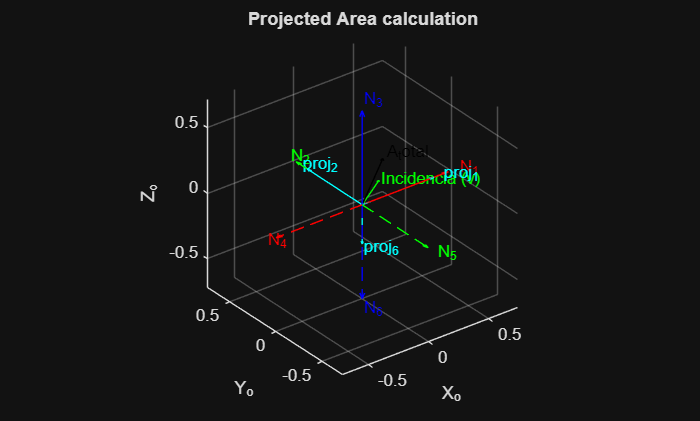

In [2]:
Areas12U = [0.06, 0.06, 0.04, 0.06, 0.06, 0.04]; % m^2
v = 7800*[1;1;-0.5]/norm([1;1;-0.5]);
Aeff = efectiveArea(v, Areas12U, [1;0;0;0], true);
title('Projected Area calculation');
xlabel('X_o'); ylabel('Y_o'); zlabel('Z_o');

In [3]:
disp(Aeff);

    0.0400
    0.0400
   -0.0133


##  **1. SPACE DISTURBANCES**

Spacecrafts are subjected to variable disturbances resulting from the various properties of the low earth orbit (LEO) environment. Approximated simple models are used for preliminary analysis. In the following part, we will present the most common disturbances of a circular orbit. The worst\-case condition for each case will serve as the basis for the design of the ADCS.

The disturbances that act on LEO spacecraft emerge from:

- The gravity gradient.
- The geomagnetic field and its interaction with residual spacecraft dipoles.
- The solar pressure.
- The aerodynamical interaction with the rarefied gas environment in earth orbit.

### **1.2. Gravity Gradient**

The external torques that affect a Satellite are various. However, for low orbit satellites, the major disturbance that a CubeSat is exposed to is the gravity gradient torque $L_{gg}$ which is defined in \[1\] and \[2\] as (1.2.1).

 $L=L_{gg} =3\omega_o^2 c_3 \times I_B c_3$       (1.2.1)

And $\omega_o$ and $c_3$ is defined in (1.2.2) and (1.2.3) respectively.

 $\omega_o^2 =\frac{\mu }{r_c^3 }$  (1.2.2)

 $c_3 =C\left(q\right)\left\lbrack \begin{array}{c} 0\newline 0\newline 1 \end{array}\right\rbrack =\left\lbrack \begin{array}{c} 2\left(q_1 q_3 -q_2 q_4 \right)\;\newline 2\left(q_2 q_3 -q_1 q_4 \right)\newline 1-2\left(q_1^2 -q_2^2 \right) \end{array}\right\rbrack$ (1.2.3)

Where:

- $\mu$: Earth’s gravitational coefficient ( $\mu =3.986\times 10^{14}$ ).
- $r_c^3$: Distance from the center of earth.
- $C(q)$: Attitude Matrix.
- $c_3$: Nadir\-pointing unit vector.

The following Code shows a function that implements the gravity gradient disturbance

<pre>
function Tgg = dist_gravityGrad(state, sat, orbit, earth)
% DIST_GRAVITYGRAD Calcula el torque por gradiente de gravedad.
% Útil para satélites con inercias asimétricas como un CubeSat 12U.

    % 1. Extraer cuaternión (asumiendo formato [q_w, q_x, q_y, q_z])
    q = state(7:10);
    q = q / norm(q); % Normalización de seguridad

    % 2. Parámetros orbitales
    % Usar mu desde la estructura earth si está disponible, sino el estándar
    if isfield(earth, 'mu')
        mu = earth.mu;
    else
        mu = 3.986004418e14; % [m^3/s^2]
    end

    rc = earth.Radius + orbit.altitude;
    omega_o_sq = mu / rc^3; % Velocidad orbital al cuadrado (w_o^2)

    % 3. Dirección del Nadir en el marco del cuerpo (Body Frame)
    % Representa la dirección hacia el centro de la Tierra
    c3 = [2*(q(2)*q(4) - q(3)*q(1));
          2*(q(3)*q(4) + q(2)*q(1));
          1 - 2*(q(2)^2 + q(3)^2)];

    % 4. Cálculo del Torque de Gradiente de Gravedad
    % Tgg = 3 * w_o^2 * (n x (I * n))
    Tgg = 3 * omega_o_sq * cross(c3, sat.Is * c3);
end
</pre>

### **1.3** **Solar Radiation Pressure (SRP)**

The pressure and the torque generated by the radiation emitted by the sun are governed by the solar constant. It is defined as the normal energy flux onto a unit area per unit time, outside of the atmosphere, at one astronomical unit (1 AU = average earth\-sun distance). The solar constant has an uncertainty of about ±10 W/m2. The normal values for the electromagnetic radiation of the sun are as follows:

- Solar constant at 1 AU 1371 W/m2
- Max. solar energy flux (European winter) 1428 W/m2
- Min. solar energy flux (European summer) 1316 W/m2

The resulting torque follows the equation (2.71).

 $T_{sp} =\frac{S_0 }{c}\ldotp A\ldotp {\left(1+q\right)}\ldotp \cos {\left(i\right)}\ldotp {\left(c_{ps} -c_g \right)}$    (2.71)

With

- $S_0$: Solar constant \[W/m²\] = 1428 W/m² (max)
- $c$ : Speed of light \[m/s\] = 3\*10\textasciicircum{}8 m/s
- $A$: Projected Area \[m²\]
- $q$: Reflectance factor (0: perfectly absorbing, 1: perfectly reflecting)
- $i$: Angle of incidence \[rad\]
- $cps-cg$: Distance between center of pressure and center of gravity \[m\]

The program is calculated in the following code

<pre>
function Tsp = dist_solRad(Aefec_vec, sat, sun_in_eclipse)
    % Aefec_vec: Vector de área efectiva [3x1] (salida de tu función anterior)
    % sat: Estructura con .q_reflec (0 a 1) y .cp_cg (brazo de palanca [3x1])
    % sun_in_eclipse: Booleano (true si está en sombra, false si hay sol)

    if sun_in_eclipse
        Tsp = [0; 0; 0];
        return;
    end

    % --- Constantes ---
    P0 = 1367; % Constante solar promedio (W/m^2)
    c  = 299792458; % Velocidad de la luz (m/s)
    P_rad = P0 / c; % Presión de radiación (~4.57e-6 N/m^2)

    % --- Cálculo de la Fuerza (F) ---
    % Usamos el vector Aefec_vec que ya trae la dirección y magnitud proyectada.
    % La fuerza actúa en la dirección opuesta al sol (dirección de incidencia).
    % Nota: (1 + q_reflec) asume reflexión especular simplificada.
    F_srp = P_rad * (1 + sat.q_reflec) * Aefec_vec;

    % --- Cálculo del Torque (T = r x F) ---
    % sat.cp_cg debe ser el vector del Centro de Masas al Centro de Presiones [3x1]
    Tsp = cross(sat.cp_cg, F_srp);
end
</pre>

### 1.4. Atmospheric Drag

To calculate the aerodynamic drag acting on the satellite, first is necessary to model the density as a function of latitude which is described as (2.72).

&#160;&#160;&#160;&#160;&#160; $\rho =\rho_0 e^{\frac{h_0 -h}{H}}$ (2.72)

Where:

- $\rho$: is the density at a specific altitude \[kg/m³\]
- $h$: is the specific altitude \[km\]
- $\rho_0$: is the reference density \[kg/m³\]
- $h_0$: is the reference altitude \[km\]
- $H$: is the scale altitude \[km\]

The model for the torque due to aerodynamic effects is described by (2.73).

 $T_a =\frac{1}{2}\rho c_D Av_c^2 {\left(c_{pa} -c_g \right)}$    (2.73)

 Where:

- $\rho$ is the density \[kg/ $m^3$ \]
- $c_D$ is the coefficient of drag (usually between 2 and 2.5).
- $A$ is the projected Area \[ $m^2$ \]
- $v_C$ is the orbital velocity \[m/s\].
- $c_{pa} -c_g$ is the distance between center of pressure and center of gravity \[m\].

 The following code presents an implementation of the Aerodynamic drag.

<pre>
function Tdrag = dist_aeroDrag(Aefec_vec, v_rel, rho, sat)
% Aefec_vec: Vector de área efectiva [3x1] (Salida de tu función efectiveArea)
% v_rel: Vector velocidad relativa a la atmósfera [3x1] (m/s)
% rho: Densidad atmosférica local (kg/m^3)
% sat: Estructura con .cd (coef. arrastre) y .cpa_cg (brazo de palanca [3x1])

    % 1. Calcular la magnitud de la velocidad
    v_mag = norm(v_rel);

    if v_mag == 0
        Tdrag = [0; 0; 0];
        return;
    end

    % 2. Calcular el vector Fuerza de Arrastre (Drag)
    % La fuerza de arrastre se opone al vector de velocidad relativa.
    % Usamos Aefec_vec que ya contiene la proyección geométrica.
    % Fd = -1/2 * rho * Cd * A_proyectada * v^2 * unit(v)

    F_drag = -0.5 * rho * sat.cd * v_mag * v_rel * norm(Aefec_vec);

    % 3. Calcular el Torque Aerodinámico (T = r x F)
    % sat.cpa_cg: Vector desde el CG al Centro de Presiones Aerodinámicas.
    Tdrag = cross(sat.cpa_cg, F_drag);
end
</pre>


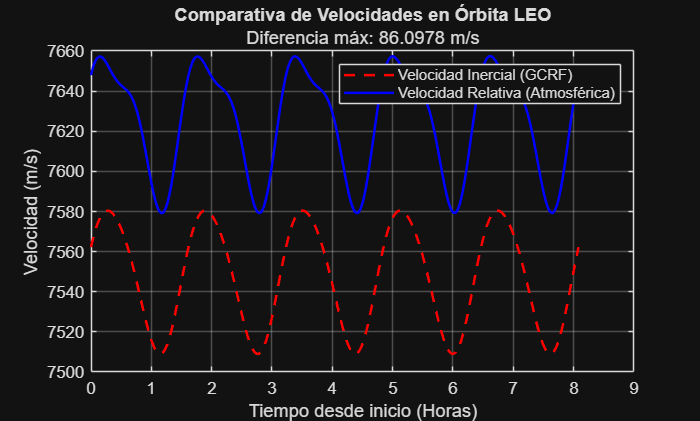

In [4]:
%% 1. INICIALIZACIÓN DE ESTRUCTURAS NRLMSISE-00
%% 1. INICIALIZACIÓN DE ESTRUCTURAS
numSteps = 300; % Definido para coincidir con tarr
atm = struct('d',zeros(9,1),'t',zeros(2));
ap_a = struct('a',zeros(7,1));
input = struct('year',0,'doy',0,'sec',0,'alt',0,'g_lat',0,'g_long',0,'lst',0,'f107A',0,'f107',0,'ap',0,'ap_a',ap_a);


% Pre-asignación de vectores de resultados
v_rel_norm = zeros(numSteps, 1);
v_iner_norm = zeros(numSteps, 1);
time_vec = zeros(numSteps, 1); % Para el eje X del gráfico


%% 2. CONSTANTES FÍSICAS Y TERRESTRES
earth.Radius       = 6378e3;
earth.Mass         = 5.972e24;
earth.GravityConst = 6.674e-11;
earth.mu           = earth.GravityConst * earth.Mass;
earth.omega_earth  = [0; 0; 7.292115e-5]; % Rotación terrestre [rad/s]


%% 3. DEFINICIÓN DE LA ÓRBITA (Sincronizada con el Sol - 614km aprox)
orbit.semiMajorAxis = 6992e3;
orbit.eccentricity  = 0.0037118;
orbit.inclination   = 97.799;
orbit.rightAscensionOfAscendingNode = 80.477;
orbit.argumentOfPeriapsis = 65.443;
orbit.trueAnomaly   = 294.681705;
orbit.period        = 2*pi/sqrt(earth.mu) * orbit.semiMajorAxis^(3/2);


%% 4. VENTANA DE TIEMPO
settings.startTime = datetime(2025,10,10,23,30,00);
settings.sampleTime = 120;
settings.number_of_orbits = 5;
settings.tfinal = orbit.period * settings.number_of_orbits;
settings.stopTime = settings.startTime + seconds(settings.tfinal);


%% 5. PROPAGADOR SGP4
sc = satelliteScenario(settings.startTime, settings.stopTime, settings.sampleTime);
sat.satSGP4 = satellite(sc, orbit.semiMajorAxis, orbit.eccentricity, orbit.inclination, ...
        orbit.rightAscensionOfAscendingNode, orbit.argumentOfPeriapsis, orbit.trueAnomaly);


tarr = linspace(settings.startTime, settings.stopTime, numSteps);


%% 6. BUCLE DE CÁLCULO (Corrección de Velocidad Relativa)
for i = 1:numSteps
    datetime_t = tarr(i);
    [pos_GCRF, vel_GCRF] = states(sat.satSGP4, datetime_t, "CoordinateFrame", "inertial");

    % Modelo Atmosférico
    [input(i), atm(i)] = callNRLsise00(pos_GCRF, datetime_t);


    % Cálculo de Velocidad Relativa (V_rel = V_iner - Omega x R)
    v_atm = cross(earth.omega_earth, pos_GCRF);
    v_rel = vel_GCRF - v_atm;

    % Almacenamiento de magnitudes
    v_rel_norm(i) = norm(v_rel);
    v_iner_norm(i) = norm(vel_GCRF);
    time_vec(i) = seconds(datetime_t - settings.startTime) / 3600; % Tiempo en horas
end


%% 7. GRÁFICA DE VELOCIDAD RELATIVA VS INERCIAL
figure('Name', 'Análisis de Velocidad Relativa');
plot(time_vec, v_iner_norm, 'r--', 'LineWidth', 1.5); hold on;
plot(time_vec, v_rel_norm, 'b', 'LineWidth', 1.5);
grid on;
title('Comparativa de Velocidades en Órbita LEO');
xlabel('Tiempo desde inicio (Horas)');
ylabel('Velocidad (m/s)');
legend('Velocidad Inercial (GCRF)', 'Velocidad Relativa (Atmosférica)');
subtitle(['Diferencia máx: ', num2str(max(abs(v_iner_norm - v_rel_norm))), ' m/s']);


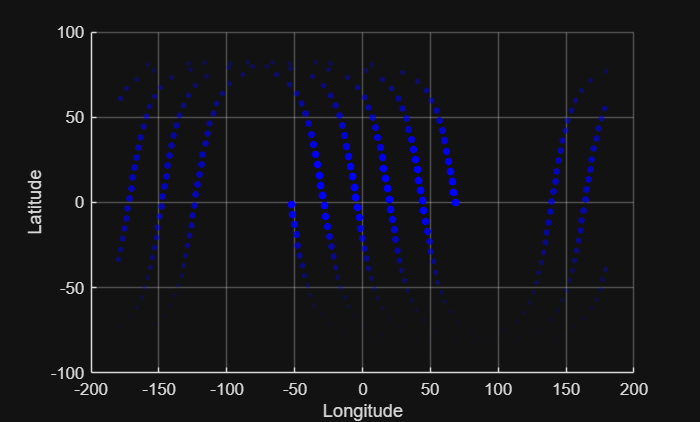

In [5]:
%% 8. VISUALIZACIÓN DE DENSIDAD ATMOSFÉRICA
figure()
averageRho = 0;
for i = 1:length(tarr)
    % Grafica la trayectoria sobre el mapa de Lat/Long.
    % El tamaño y transparencia de los puntos representan la densidad total (d(6)).
    scatter(input(i).g_long, input(i).g_lat, atm(i).d(6)*5e13, 'filled',...
        'AlphaData', atm(i).d(6)*3e13, 'MarkerFaceColor', 'blue', 'MarkerFaceAlpha', 'flat');
    averageRho = averageRho + atm(i).d(6);
    hold on;
end
averageRho = averageRho / length(tarr);


% Formateo de gráfico
title(['NRLMSISE00 Atmospheric Model: Average \rho :', num2str(averageRho), ' (kg/m^3)']);
xlabel('Longitude'); ylabel('Latitude'); grid on;


### 1.5. Geomagnetic interaction

The spacecraft's motion across the geomagnetic field induces an electromagnetic field in the spacecraft, which in return interacts with the geomagnetic field, generating a disturbance torque that can be expressed by (2.74).

&#160;&#160;&#160;&#160;&#160; ${\overset{-}{T} }_m =\overset{-}{D} x\overset{-}{B}$       (2.74)

  With:

- D: is residual magnetic dipole vector.
- B: is local geomagnetic field vector.

In the worst possible case, the vectors are perpendicular to each other, and the worst moment is described as (2.75).

&#160;&#160;&#160;&#160;&#160; $T_m =D\frac{2M}{R^3 }$ (2.75)

## 1.3. Satellite Simulations (Ideal Case)

#### 1.3.1 Satellite Dynamics

We use the rotational Dynamics equation

$$\dot{\omega} =[I]^{-1} [T_c +T_d -\omega \times ([I]\omega )]$$

- $I$: Satellite Inertia tensor.
- $T_c$: Torque Controll
- $T_d$: Disturbances torque (Gravity Gradient)
- $\omega$: Angular rate

The translation Dynamics

$$\ddot{x} =\frac{F_g }{m}+a_{pert}$$

- $F_g$: Gravitational Force.
- m: Satellite mass.
- $a_{pert}$: Disturbances
- $x$: Satellite position.

$$F_g =\frac{-GMm}{|x|^2 }\frac{x}{|x|}$$

- $G$: Gravitational constant 6.668E\-11 m\textasciicircum{}3 / kg \- s\textasciicircum{}2
- M: Earth mass.
- m: Satellite mass
- x: satellite positiom

Kinematic equation in quaternions

$$\dot{q} =\frac{1}{2}\Xi (q)$$

Where $\Xi (q)$ is described by equation (1.3.2).

$$\Xi \left(q\right)=\left\lbrack \begin{array}{ccc} q_4  & -q_3  & q_2 \newline q_3  & q_4  & -q_1 \newline -q_2  & q_1  & q_4 \newline -q_1  & -q_2  & -q_3  \end{array}\right\rbrack$$

**1.3.3. Satellite Parameters**

Clear and errase variables.


In [6]:
%%% Clear previous variables
clearvars -except animationsGraphs
clear persistent
clear global
clc


- **Satellite inertia**


In [7]:
%% 1) PARÁMETROS DEL SATÉLITE (12U ESTÁNDAR)
% Momentos de Inercia [kg*m^2]
Ixx = 0.2785; Iyy = 0.2792; Izz = 0.1705;
Ixy = -0.005; Ixz = 0.003; Iyz = 0.004;


sat.Is = [Ixx,  Ixy,  Ixz;
          Ixy,  Iyy,  Iyz;
          Ixz,  Iyz,  Izz];


sat.mass = 20.0; % Masa máxima para un 12U denso


% Áreas reales de las caras (X+, Y+, Z+, X-, Y-, Z-) en m^2
% Caras laterales: 0.2m * 0.3m | Caras sup/inf: 0.2m * 0.2m
sat.faceAreas = [0.06, 0.06, 0.04, 0.06, 0.06, 0.04];


% Propiedades de superficie
sat.q_reflec = 0.62; % 1 - 0.38 (Aluminio 6061-T6)
sat.cd = 2.2;       % Coeficiente de arrastre típico para CubeSats


% Centro de Presiones vs Centro de Gravedad [m]
sat.cps_cg = [0.01; -0.005; 0.02]; % [x; y; z] en metros


- **Earth Parameters**


In [8]:
%%%% Planet parameters (WGS-84 / EGM96 Standard)
earth.Radius       = 6378137.0;                % Semi-major axis (m)
earth.Mass         = 5.9722E24;                % Planet Mass (kg)
earth.GravityConst = 6.67430E-11;              % G constant (N m^2/kg^2)
earth.mu           = 3.986004418E14;           % Earth's gravitational parameter (m^3/s^2)
earth.omega_e      = 7.292115E-5;              % Earth's angular velocity (rad/s)
earth.J2           = 1.08262668E-3;            % Second dynamic form factor (flatness)
earth.f            = 1/298.257223563;          % Earth flattening


- **Orbit Parameters**


In [9]:
%% Orbit Parameters
%% 3. DEFINICIÓN DE LA ÓRBITA (Sincronizada con el Sol - 614km aprox)
orbit.semiMajorAxis = 6992e3;
orbit.eccentricity  = 0.0037118;
orbit.inclination   = 97.799;
orbit.rightAscensionOfAscendingNode = 80.477;
orbit.argumentOfPeriapsis = 65.443;
orbit.trueAnomaly   = 294.681705;
% Parámetros derivados
orbit.period   = 2*pi/sqrt(earth.mu) * orbit.semiMajorAxis^(3/2);
% Altitud media para modelos de perturbaciones
orbit.altitude = orbit.semiMajorAxis - earth.Radius;
% Translational velocity
orbit.vcircular = sqrt(earth.mu / orbit.semiMajorAxis);


- **Satellite Disturbances**


In [10]:
%%% External disturbances
disturbance = @(state) dist_gravityGrad(state,sat,orbit,earth);
%disturbance2 = @(state) dist_gravityGrad(state,sat,orbit,earth);


- **Initial conditions**


In [11]:
%% Initial Conditions
%%% Initial position in the fixed inertial frame (x,y,z)
initial.X.x0 = earth.Radius + orbit.altitude;     % Initial position x
initial.X.y0 = 0;                                 % Initial position y
initial.X.z0 = 0;                                 % Initial position z
%%%Calculate initial displacement rates
initial.Xdot.xdot0 = 0;
initial.Xdot.ydot0 = orbit.vcircular*cos(orbit.inclination);
initial.Xdot.zdot0 = orbit.vcircular*sin(orbit.inclination);
%%% Intitial Conditions for Attitude and Angular Velocity (Euler angles)
initial.atitude.rpy0_deg(1)    = 0;           %  Initial Roll  (deg)
initial.atitude.rpy0_deg(2)    = 0;           %  Initial Pitch (deg)
initial.atitude.rpy0_deg(3)    = 0;           %  Initial Yaw   (deg)
%%% Initial Euler Angles and quaternions
initial.atitude.rpy0_rad    = deg2rad([initial.atitude.rpy0_deg(1),...
    initial.atitude.rpy0_deg(2),...
    initial.atitude.rpy0_deg(3)]');       % Euler Angles (rad)
initial.atitude.q0123_0 = eul2quat(initial.atitude.rpy0_rad')';  % Quaternions
%%% Initial angular rates in the body frame (rad/s)
initial.omega.omega0_x = 0.0;
initial.omega.omega0_y = 0.0;
initial.omega.omega0_z = 0.0;


#### 1.3.4. Start Satellite Simulation (IDEAL CASE)


In [12]:
%%% Global variables
global varNames curValues varValues
varNames = {'Td'};
curValues = struct(); varValues = struct();


- **Simulation Settings**


In [13]:
%% Simulation Parameters
%%% Setting Time Window (just 5 orbit)
settings.number_of_orbits = 5;
settings.tfinal = orbit.period*settings.number_of_orbits;
%%% Satellite initial states
settings.X0 = [initial.X.x0;            initial.X.y0;        initial.X.z0; ...
    initial.Xdot.xdot0; initial.Xdot.ydot0; initial.Xdot.zdot0; ...
    initial.atitude.q0123_0;            initial.omega.omega0_x; ...
    initial.omega.omega0_y ;            initial.omega.omega0_z];


- **Simulation**


In [14]:
%% Solve by variable step Runge Kutta of 4 order
tic
opts = odeset('InitialStep',1e-4,'RelTol',1e-6,'Events', @(t, x) store_var(t, x));
settings.hWaitbar = waitbar(0, 'Progress: 0%','Name', 'LINKU-ABC Simulation Progress');
[tout,x] = ode45(@(t,x) satelliteSim(t, x, sat, earth, disturbance, settings),...
    [0 settings.tfinal],settings.X0,opts);
elapsedTime = toc;


%%%Recover disturbances
dis_v = zeros(3,length(x));
for i = 1:length(x)
    dis_v(:,i) = disturbance(x(i,:));
end
% Print the elapsed time in seconds
fprintf('Elapsed time: %.3f miliseconds\n',elapsedTime*1000);

Elapsed time: 8251.513 miliseconds


#### **1.3.5. Plot Simulation**



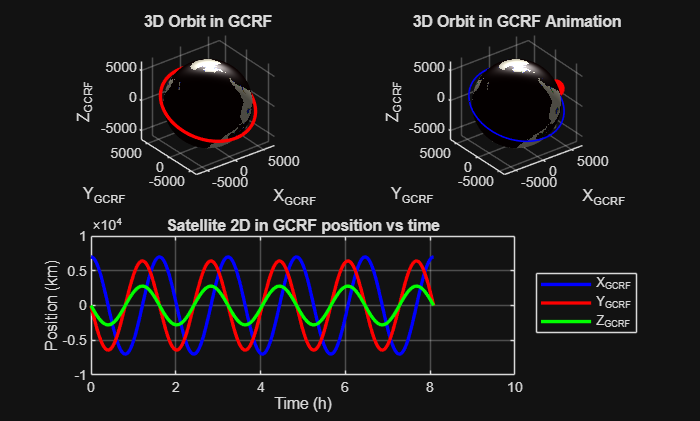

In [15]:
%% Rename index
xyzout =   x(:,1:3);                            %%Satellite position(m)
q0123out = x(:,7:10);                           %%Satellite quaternions
ptpout = quat2eul(q0123out);                    %%Satellite euler angles
pqrout = x(:,11:13);                            %%Angular Rates


%%% Build Earth
load('topo.mat', 'topo', 'topomap1');
[rows, cols] = size(topo);


% Crear coordenadas esféricas que coincidan con el tamaño de topo (180x360)
theta = linspace(90, -90, rows); % Latitud
phi = linspace(0, 360, cols);    % Longitud
[Phi, Theta] = meshgrid(phi, theta);


% Convertir a coordenadas Cartesianas (Radio en Km para el plot)
R = earth.Radius / 1000;
X = R * cosd(Theta) .* cosd(Phi);
Y = R * cosd(Theta) .* sind(Phi);
Z = R * sind(Theta);


figure();
%%%Plot 2D position in GCRF
subplot(2,1,2);
    plot(tout/3600,xyzout(:,1)/1E3,'b-','LineWidth',2); hold on; grid on;
    plot(tout/3600,xyzout(:,2)/1E3,'r-','LineWidth',2);
    plot(tout/3600,xyzout(:,3)/1E3,'g-','LineWidth',2);
    xlabel('Time (h)'); ylabel('Position (km)');
    legend('X_{GCRF}','Y_{GCRF}','Z_{GCRF}','Location','eastoutside');
    title('Satellite 2D in GCRF position vs time');
%% Plot 3D position in GCRF
subplot(2,2,1)
    %%%Draw earth in Km and satellite orbit
    plot3(xyzout(:,1)/1000,xyzout(:,2)/1000,xyzout(:,3)/1000,'r:','LineWidth',2);
    xlabel('X_{GCRF}'); ylabel('Y_{GCRF}'); zlabel('Z_{GCRF}'); grid on; hold on;
    surf(X, Y, Z,topo,'EdgeColor', 'none', 'FaceColor', 'texturemap', 'CDataMapping', 'direct');
    colormap(topomap1); axis equal;
    %%%Set view and ilumination
    light('Position', [1 1 1]); lighting gouraud; view(3);
    %%%Add title
    title('3D Orbit in GCRF')

% Draw earth in Km and satellite orbit
subplot(2,2,2);
    h1 = plot3(xyzout(1,1)/1000,xyzout(1,2)/1000,xyzout(1,3)/1000,'ro','LineWidth',5); hold on; %#ok
    plot3(xyzout(:,1)/1000,xyzout(:,2)/1000,xyzout(:,3)/1000,'b:','LineWidth',1);
    xlabel('X_{GCRF}'); ylabel('Y_{GCRF}'); zlabel('Z_{GCRF}');
    grid on; hold on;
    surf(X, Y, Z,topo,'EdgeColor', 'none', 'FaceColor', 'texturemap', 'CDataMapping', 'direct');
    colormap(topomap1);
    axis equal
    % Set view and ilumination
    light('Position', [1 1 1]);
    lighting gouraud;
    view(3);
    % Add title
    title('3D Orbit in GCRF Animation')

In [16]:
    if animationsGraphs
        for i = 1:length(x) %#ok
            set(h1, 'XData', xyzout(i,1)/1000, 'YData', xyzout(i,2)/1000, 'ZData',xyzout(i,3)/1000);
            pause(0.01);
        end
    end



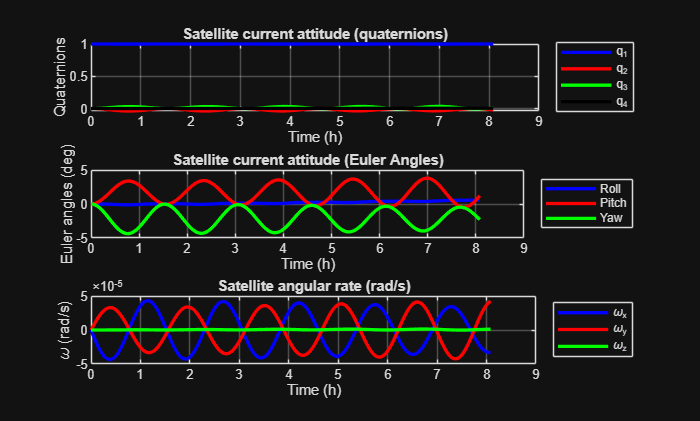

In [17]:
figure();
subplot(3,1,1)
h1 = plot(tout/3600,q0123out(:,1),'b-','LineWidth',2);
hold on
grid on
h2 = plot(tout/3600,q0123out(:,2),'r-','LineWidth',2);
h3 = plot(tout/3600,q0123out(:,3),'g-','LineWidth',2);
h4 = plot(tout/3600,q0123out(:,4),'k-','LineWidth',2);
xlabel('Time (h)');
ylabel('Quaternions');
legend([h1,h2,h3,h4],'q_1','q_2','q_3','q_4','Location','eastoutside');
title('Satellite current attitude (quaternions)');


subplot(3,1,2)
h1 = plot(tout/3600,rad2deg(ptpout(:,1)),'b-','LineWidth',2);
hold on
grid on
h2 = plot(tout/3600,rad2deg(ptpout(:,2)),'r-','LineWidth',2);
h3 = plot(tout/3600,rad2deg(ptpout(:,3)),'g-','LineWidth',2);
xlabel('Time (h)');
ylabel('Euler angles (deg)');
legend([h1,h2,h3],'Roll','Pitch','Yaw','Location','eastoutside');
title('Satellite current attitude (Euler Angles)');
subplot(3,1,3)
h1 = plot(tout/3600,pqrout(:,1),'b-','LineWidth',2);
hold on
grid on
h2 = plot(tout/3600,pqrout(:,2),'r-','LineWidth',2);
h3 = plot(tout/3600,pqrout(:,3),'g-','LineWidth',2);
xlabel('Time (h)');
ylabel('\omega (rad/s)');
legend([h1,h2,h3],'\omega_x','\omega_y','\omega_z','Location','eastoutside');
title('Satellite angular rate (rad/s)');


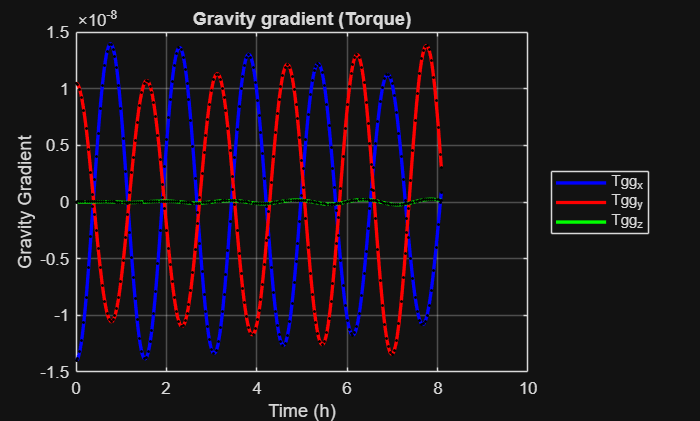

In [18]:
figure();
h1 = plot(tout/3600,dis_v(1,:),'b-','LineWidth',2);
hold on; grid on;
h2 = plot(tout/3600,dis_v(2,:),'r-','LineWidth',2);
h3 = plot(tout/3600,dis_v(3,:),'g-','LineWidth',2);
p = plot(varValues.time/3600,varValues.Td,'k.','MarkerSize',5);
xlabel('Time (h)');
ylabel('Gravity Gradient');
legend([h1,h2,h3],'Tgg_x','Tgg_y','Tgg_z','Location','eastoutside');
title('Gravity gradient (Torque)');


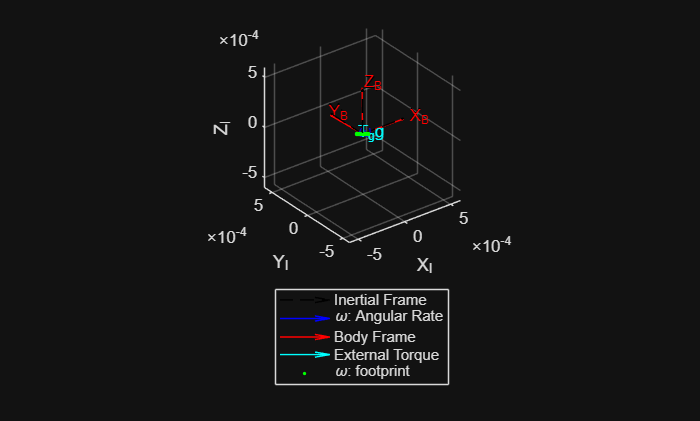

In [19]:
figure()
%%Plot settings
scaleFrames = 5E-4; scaleAngRate = 1; scaleTgg = 1;


%% Rename index
q0123out = x(:,7:10);       %%Satellite quaternions
pqrout = x(:,11:13);        %%Angular Rates


%%% Plot inertia frame I
[h1,~] = plotVector(zeros(1,3), [1,0,0], scaleFrames, 'k--', 'X_I', 'e'); hold on
plotVector(zeros(1,3), [0,1,0], scaleFrames, 'k--', 'Y_I', 'e');
plotVector(zeros(1,3), [0,0,1], scaleFrames, 'k--', 'Z_I', 'e');
plotPoint (zeros(1,3), 'k.', 'O_I', -0.08);


%%% Allocate variables
%wout_i_V = struct();
wout_i_V = zeros(3,length(x));
ri_v     = struct();
tgg_v    = struct();


for i = 1:length(x)
        %Calculate rotation Matrix arround u axis
        axisx = quatRotation(q0123out(i,:)',[1,0,0]');
        axisy = quatRotation(q0123out(i,:)',[0,1,0]');
        axisz = quatRotation(q0123out(i,:)',[0,0,1]');
        ri_v.(['n_',num2str(i)]) = [axisx',axisy',axisz'];
        %Calculate rotated angular rate
        wout_i = quatRotation(q0123out(i,:)',pqrout(i,:)');
        wout_i_V(:,i) = wout_i';
        %Calculate rotated rate
        tgg_i = quatRotation(q0123out(i,:)',pqrout(i,:)');
        tgg_v.(['n_',num2str(i)]) = tgg_i';
end


if animationsGraphs
    %%% Plot angular rate
    [h2,  h3]  = plotVector(zeros(1,3), quatRotation(q0123out(1,:)',pqrout(1,:)') ,scaleAngRate,'b-','\omega','e');%#ok

    %%% Plot Body Frame
    [h4,  h5]  = plotVector(zeros(1,3), quatRotation(q0123out(1,:)',[1,0,0]'),scaleFrames, 'r-', 'X_B', 'e');
    [h6,  h7]  = plotVector(zeros(1,3), quatRotation(q0123out(1,:)',[0,1,0]'),scaleFrames, 'r-', 'Y_B', 'e');
    [h8,  h9]  = plotVector(zeros(1,3), quatRotation(q0123out(1,:)',[0,0,1]'),scaleFrames, 'r-', 'Z_B', 'e');

    %%% Plot External torque
    [h10,  h11]  = plotVector(zeros(1,3), quatRotation(q0123out(1,:)', dis_v(:,1)),scaleTgg, 'c-', 'T_gg', 'e');
    xlim([-6E-4 6E-4]); ylim([-6E-4 6E-4]); zlim([-6E-4 6E-4]);
    xlabel('X_I'); ylabel('Y_I'); zlabel('Z_I');


    for i =  1:length(x)
        Wb  = wout_i_V(:,i)*scaleAngRate;
        B   = ri_v.(['n_',num2str(i)])*scaleFrames;
        tgg = tgg_v.(['n_',num2str(i)])*scaleTgg;

        h12 = plot3(Wb(1),Wb(2),Wb(3),'g.');

        set(h2, 'UData', Wb(1), 'VData', Wb(2), 'WData', Wb(3));
        set(h3, 'Position', Wb);

        set(h4, 'UData', B(1,1), 'VData', B(2,1), 'WData', B(3,1));
        set(h5, 'Position', B(:,1));

        set(h6, 'UData', B(1,2), 'VData', B(2,2), 'WData', B(3,2));
        set(h7, 'Position', B(:,2));

        set(h8, 'UData', B(1,3), 'VData', B(2,3), 'WData', B(3,3));
        set(h9, 'Position', B(:,3));

        set(h10, 'UData', tgg(1), 'VData', tgg(2), 'WData', tgg(3));
        set(h11, 'Position', tgg);

        %%% Pause animation
        pause(0.01);
    end
else
    %%% Plot angular rate
    [h2,  ~]  = plotVector(zeros(1,3), quatRotation(q0123out(end,:)',pqrout(end,:)') ,scaleAngRate,'b-','\omega','e');

    %%% Plot Body Frame
    [h4,  h5]  = plotVector(zeros(1,3), quatRotation(q0123out(end,:)',[1,0,0]'),scaleFrames, 'r-', 'X_B', 'e');
    [h6,  h7]  = plotVector(zeros(1,3), quatRotation(q0123out(end,:)',[0,1,0]'),scaleFrames, 'r-', 'Y_B', 'e');
    [h8,  h9]  = plotVector(zeros(1,3), quatRotation(q0123out(end,:)',[0,0,1]'),scaleFrames, 'r-', 'Z_B', 'e');

    %%% Plot footprint
    h12 = plot3(wout_i_V(1,:),wout_i_V(2,:),wout_i_V(3,:),'g.');

    %%% Plot External torque
    [h10,  h11]  = plotVector(zeros(1,3), tgg_v.(['n_',num2str(length(x))]),1, 'c-', 'T_gg', 'e');
    xlim([-6E-4 6E-4]); ylim([-6E-4 6E-4]); zlim([-6E-4 6E-4]);
    xlabel('X_I'); ylabel('Y_I'); zlabel('Z_I');
end
legend([h1,h2,h4,h10,h12],'Inertial Frame','\omega: Angular Rate','Body Frame','External Torque','\omega: footprint','Location','southoutside')


#### 1.3.5. Start Satellite Simulation (With SPG4 propagator)

**1.3.3. Satellite Parameters**

Clear and errase variables.


In [21]:
%%% Clear previous variables
clearvars -except animationsGraphs
clear persistent
clear global
clc


- **Satellite inertia**


In [22]:
%% 1) PARÁMETROS DEL SATÉLITE (12U ESTÁNDAR)
% Momentos de Inercia [kg*m^2]
Ixx = 0.2785; Iyy = 0.2792; Izz = 0.1705;
Ixy = -0.005; Ixz = 0.003; Iyz = 0.004;


sat.Is = [Ixx,  Ixy,  Ixz;
          Ixy,  Iyy,  Iyz;
          Ixz,  Iyz,  Izz];


sat.mass = 20.0; % Masa máxima para un 12U denso


% Áreas reales de las caras (X+, Y+, Z+, X-, Y-, Z-) en m^2
% Caras laterales: 0.2m * 0.3m | Caras sup/inf: 0.2m * 0.2m
sat.faceAreas = [0.06, 0.06, 0.04, 0.06, 0.06, 0.04];


% Propiedades de superficie
sat.q_reflec = 0.62; % 1 - 0.38 (Aluminio 6061-T6)
sat.cps_cg = -5E-2 + (2*5E-2).*rand(3,1); %random displacement up to 5cm. (m)
sat.cd = 2 + (2.5-2).*rand(1,1);          %between 2 and 2.5cm
sat.cpa_cg = -0.05 + (0.10) .* rand(3,1); %random displacement up to 5cm. (m)


- **Earth Parameters**


In [23]:
%%%%This will define all of our planet parameters
earth.Radius       = 6378137.0;                % Semi-major axis (m)
earth.Mass         = 5.9722E24;                % Planet Mass (kg)
earth.GravityConst = 6.67430E-11;              % G constant (N m^2/kg^2)
earth.mu           = 3.986004418E14;           % Earth's gravitational parameter (m^3/s^2)
earth.omega_e      = 7.292115E-5;              % Earth's angular velocity (rad/s)
earth.J2           = 1.08262668E-3;            % Second dynamic form factor (flatness)
earth.f            = 1/298.257223563;          % Earth flattening


- **Orbit Parameters**


In [24]:
%% Orbit Parameters
%% 3. DEFINICIÓN DE LA ÓRBITA (Sincronizada con el Sol - 614km aprox)
orbit.semiMajorAxis = 6992e3;
orbit.eccentricity  = 0.0037118;
orbit.inclination   = 97.799;
orbit.rightAscensionOfAscendingNode = 80.477;
orbit.argumentOfPeriapsis = 65.443;
orbit.trueAnomaly   = 294.681705;
% Parámetros derivados
orbit.period   = 2*pi/sqrt(earth.mu) * orbit.semiMajorAxis^(3/2);
% Altitud media para modelos de perturbaciones
orbit.altitude = orbit.semiMajorAxis - earth.Radius;
% Translational velocity
orbit.vcircular = sqrt(earth.mu / orbit.semiMajorAxis);
orbit.atmdensity  = 2.5785e-13;                         % Average density calculated by NRLMSISE00


- **Satellite Disturbances**


In [25]:
%%% External diisturbances
disturbance1 = @(state) dist_gravityGrad(state,sat,orbit,earth);
disturbance2 = @(projA) dist_solRad(projA,sat,false);
disturbance3 = @(projA,vel) dist_aeroDrag(projA, vel, orbit.atmdensity, sat);


- **Initial conditions**


In [26]:
%% Initial Conditions
%%% Intitial Conditions for Attitude and Angular Velocity (Euler angles)
initial.atitude.rpy0_deg(1)    = 0;           %  Initial Roll  (deg)
initial.atitude.rpy0_deg(2)    = 0;           %  Initial Pitch (deg)
initial.atitude.rpy0_deg(3)    = 0;           %  Initial Yaw   (deg)
%%% Initial Euler Angles and quaternions
initial.atitude.rpy0_rad    = deg2rad([initial.atitude.rpy0_deg(1),...
    initial.atitude.rpy0_deg(2),...
    initial.atitude.rpy0_deg(3)]');       % Euler Angles (rad)
initial.atitude.q0123_0 = eul2quat(initial.atitude.rpy0_rad')';  % Quaternions
%%% Initial angular rates in the body frame (rad/s)
initial.omega.omega0_x = 0.0;
initial.omega.omega0_y = 0.0;
initial.omega.omega0_z = 0.0;


#### 1.3.4. Start Satellite Simulation (SPG4 propagator)
- **Simulation Settings**


In [27]:
%% Simulation Parameters
%%% Setting Time Window (just 5 orbit)
settings.startTime = datetime(2025,10,10,23,30,00);
settings.sampleTime = 500;
settings.number_of_orbits = 100;
settings.tfinal = orbit.period*settings.number_of_orbits;
settings.stopTime = settings.startTime  + seconds(orbit.period*settings.number_of_orbits);


%%% Satellite initial states
settings.X0 = [initial.atitude.q0123_0; initial.omega.omega0_x; ...
               initial.omega.omega0_y ; initial.omega.omega0_z];


%% Create satellite scenario to use SPG4 propagator
sc = satelliteScenario(settings.startTime ,settings.stopTime,settings.sampleTime);
sat.satSGP4 = satellite(sc, orbit.semiMajorAxis, orbit.eccentricity, orbit.inclination, ...
        orbit.rightAscensionOfAscendingNode, orbit.argumentOfPeriapsis, orbit.trueAnomaly);


- **Simulation**


In [28]:
%% Solve by variable step Runge Kutta of 4 order and use SPG4 propagator
tic
settings.hWaitbar = waitbar(0, 'Progress: 0%','Name', 'LINKU-ABC Simulation Progress');
% Función de eventos para almacenar u(t) en cada paso
opts = odeset('InitialStep',1e-4,'RelTol',1e-6);
[tout,x] = ode45(@(t,x) satelliteSPG4sim(t, x, sat, disturbance1, disturbance2, disturbance3,...
    settings),[0 settings.tfinal],settings.X0,opts);
elapsedTime = toc;


%%%Recover disturbances
%%%Allocate variables
dis_tgg   = zeros(3,length(x));
sun_avail = zeros(1,length(x));
dis_solar = zeros(3,length(x));
dis_drag  = zeros(3,length(x));
totaltorque = zeros(3,length(x));
normTtorque = zeros(1,length(x));
xyzout = zeros(3,length(x));
for i = 1:length(x)
    %%%Recover time
    datetime_t  = settings.startTime  + seconds(tout(i));
    %%%Recover Position
    [positionGCRF, velGCRF] = states(sat.satSGP4,datetime_t,"CoordinateFrame", "inertial");
    %%% Get sun position
    [sun_i,r_sun] = solar(datetime_t.Year,datetime_t.Month,datetime_t.Day,datetime_t.Hour,datetime_t.Minute,datetime_t.Second);
    %%%Determine eclipse condition
    sun_avail(i) = eclipse(positionGCRF*1e-3,r_sun*1e-3*sun_i);
    %%% Get rotation matrix from orbit to inertia
    oX=getUnitVector(velGCRF); oZ=-1*getUnitVector(positionGCRF); oY=cross(oZ,oX);
    rot_orbit_I=horzcat(oX,oY,oZ);


    %%% Get distubance
    dis_tgg(:,i)   = disturbance1([zeros(1,6),x(i,:)]);


    %%% Get drag disturbance
    AefecDrag = efectiveArea(quatRotation(quatconj(x(i,1:4)),[1,0,0]'), sat.faceAreas, [1;0;0;0], false);
    dis_drag(:,i) = disturbance3(AefecDrag,velGCRF);


    %%% Get solar disturbance
    if sun_avail(i) == 1
        sun_orbit = rot_orbit_I'*sun_i';
        Aefecb = efectiveArea(quatRotation(quatconj(x(i,1:4)),sun_orbit),sat.faceAreas,[1;0;0;0],false);        %%Efective area in body frame
        dis_solar(:,i) = disturbance2(Aefecb);
    else
        dis_solar(:,i) = zeros(3, 1);
    end
    totaltorque(:,i) = dis_tgg(:,i)+dis_drag(:,i)+dis_solar(:,i);
    normTtorque(i) = norm(totaltorque(:,i));
    xyzout(:,i) = states(sat.satSGP4,datetime_t,"CoordinateFrame", "ecef");
end
%totaltorque = dis_tgg+dis_drag+dis_solar;
% Print the elapsed time in seconds
fprintf('Elapsed time: %.3f miliseconds\n',elapsedTime*1000);

Elapsed time: 158426.428 miliseconds


If simulation is already runing, just recover its results


In [29]:
% fileName = {'sat_param.mat','sat_positions.mat','sat_states.mat','sat_times.mat',...
%     'sunAvailable.mat','tdrag.mat','tgg.mat','tnorm.mat','tsolar.mat','tTotal.mat'};
% for i = 1:length(fileName)
%     load(fileName{1,i});
% end


Plot new figures with the new project



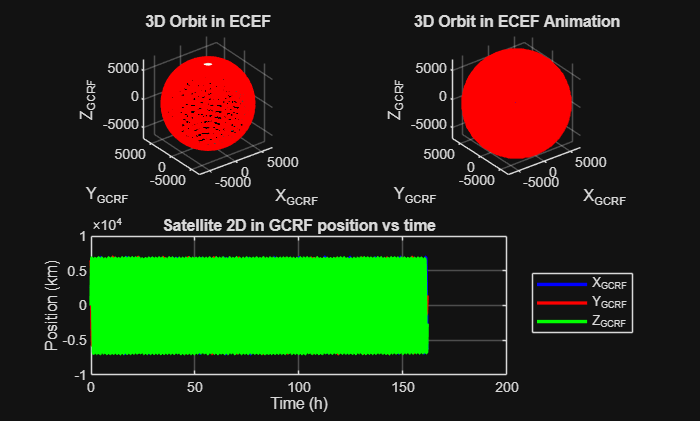

In [30]:
%% Rename index
q0123out = x(:,1:4);                           %%Satellite quaternions
ptpout = quat2eul(q0123out);    %%Satellite euler angles
pqrout = x(:,5:7);                             %%Angular Rates


%% Plot 2D position
%%%Plot satellite position as a function of time
figure();
    subplot(2,1,2);
    plot(tout/3600,xyzout(1,:)/1E3,'b-','LineWidth',2); hold on; grid on;
    plot(tout/3600,xyzout(2,:)/1E3,'r-','LineWidth',2);
    plot(tout/3600,xyzout(3,:)/1E3,'g-','LineWidth',2);
    xlabel('Time (h)'); ylabel('Position (km)');
    legend('X_{GCRF}','Y_{GCRF}','Z_{GCRF}','Location','eastoutside');
    title('Satellite 2D in GCRF position vs time');


%% Plot 3D position
subplot(2,2,1)

    %%% Build Earth
    load('topo.mat', 'topo', 'topomap1');
    [rows, cols] = size(topo);

    % Crear coordenadas esféricas que coincidan con el tamaño de topo (180x360)
    theta = linspace(90, -90, rows); % Latitud
    phi = linspace(0, 360, cols);    % Longitud
    [Phi, Theta] = meshgrid(phi, theta);

    % Convertir a coordenadas Cartesianas (Radio en Km para el plot)
    R = earth.Radius / 1000;
    X = R * cosd(Theta) .* cosd(Phi);
    Y = R * cosd(Theta) .* sind(Phi);
    Z = R * sind(Theta);


    %%%Draw earth in Km and satellite orbit
    h0 = plot3(xyzout(1,:)/1000,xyzout(2,:)/1000,xyzout(3,:)/1000,'r:','LineWidth',2);
    xlabel('X_{GCRF}'); ylabel('Y_{GCRF}'); zlabel('Z_{GCRF}')
    grid on
    hold on
    surf(X, Y, Z,topo,'EdgeColor', 'none', 'FaceColor', 'texturemap', 'CDataMapping', 'direct');
    %legend(h0,'Satellite orbit (Km)','Location','southoutside');
    colormap(topomap1);
    axis equal
    %%%Set view and ilumination
    light('Position', [1 1 1]);
    lighting gouraud;
    view(3);
    %%%Add title
    title('3D Orbit in ECEF')

% Draw earth in Km and satellite orbit
subplot(2,2,2);
    h1 = plot3(xyzout(1,:)/1000,xyzout(2,:)/1000,xyzout(3,:)/1000,'ro','LineWidth',5);
    hold on;
    plot3(xyzout(1,:)/1000,xyzout(2,:)/1000,xyzout(3,:)/1000,'b:','LineWidth',1);
    xlabel('X_{GCRF}'); ylabel('Y_{GCRF}'); zlabel('Z_{GCRF}');
    grid on; hold on;
    surf(X, Y, Z,topo,'EdgeColor', 'none', 'FaceColor', 'texturemap', 'CDataMapping', 'direct');
    colormap(topomap1);
    axis equal
    % Set view and ilumination
    light('Position', [1 1 1]);
    lighting gouraud;
    view(3);
    % Add title
    title('3D Orbit in ECEF Animation')

In [31]:


% for i = 1:length(x)
%     set(h1, 'XData', xyzout(1,i)/1000, 'YData', xyzout(2,i)/1000, 'ZData',xyzout(3,i)/1000);
%     pause(0.01);
% end


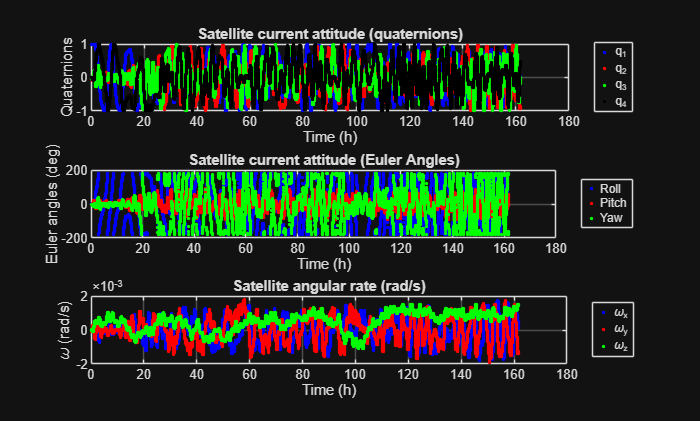

In [32]:
figure();
p1 = subplot(3,1,1);
h1 = plot(tout/3600,q0123out(:,1),'b.','LineWidth',0.1);
hold on;
grid on
h2 = plot(tout/3600,q0123out(:,2),'r.','LineWidth',0.1);
h3 = plot(tout/3600,q0123out(:,3),'g.','LineWidth',0.1);
h4 = plot(tout/3600,q0123out(:,4),'k.','LineWidth',0.1);
xlabel('Time (h)');
ylabel('Quaternions');
legend([h1,h2,h3,h4],'q_1','q_2','q_3','q_4','Location','eastoutside');
title('Satellite current attitude (quaternions)');


p2=subplot(3,1,2);
h1 = plot(tout/3600,rad2deg(ptpout(:,1)),'b.','LineWidth',0.1);
hold on
grid on
h2 = plot(tout/3600,rad2deg(ptpout(:,2)),'r.','LineWidth',0.1);
h3 = plot(tout/3600,rad2deg(ptpout(:,3)),'g.','LineWidth',0.1);
xlabel('Time (h)');
ylabel('Euler angles (deg)');
legend([h1,h2,h3],'Roll','Pitch','Yaw','Location','eastoutside');
title('Satellite current attitude (Euler Angles)');


p3=subplot(3,1,3);
h1 = plot(tout/3600,pqrout(:,1),'b.','LineWidth',0.1);
hold on
grid on
h2 = plot(tout/3600,pqrout(:,2),'r.','LineWidth',0.1);
h3 = plot(tout/3600,pqrout(:,3),'g.','LineWidth',0.1);
xlabel('Time (h)');
ylabel('\omega (rad/s)');
legend([h1,h2,h3],'\omega_x','\omega_y','\omega_z','Location','eastoutside');
title('Satellite angular rate (rad/s)');
linkaxes([p1,p2,p3],'x');


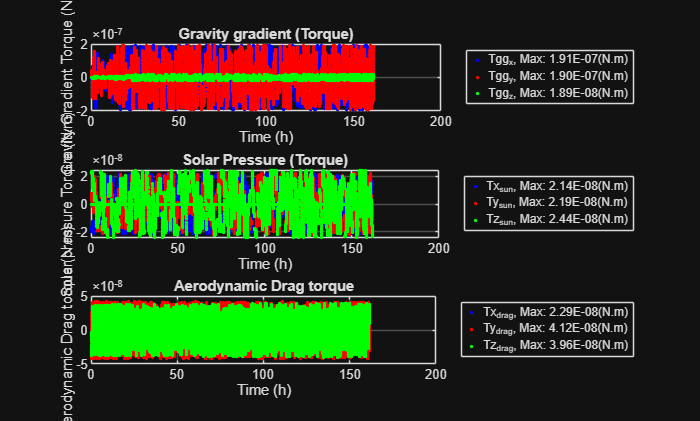

In [33]:
figure();
p1=subplot(3,1,1);
h1 = plot(tout/3600,dis_tgg(1,:),'b.','LineWidth',0.5);
hold on; grid on;
h2 = plot(tout/3600,dis_tgg(2,:),'r.','LineWidth',0.5);
h3 = plot(tout/3600,dis_tgg(3,:),'g.','LineWidth',0.5);
xlabel('Time (h)');
ylabel('Gravity Gradient Torque (N.m)');
legend([h1,h2,h3],['Tgg_x, Max: ', num2str(max(dis_tgg(1,:)),'%.2E'),'(N.m)'],...
                  ['Tgg_y, Max: ', num2str(max(dis_tgg(2,:)),'%.2E'),'(N.m)'],...
                  ['Tgg_z, Max: ', num2str(max(dis_tgg(3,:)),'%.2E'),'(N.m)'],'Location','eastoutside');
title('Gravity gradient (Torque)');


p2=subplot(3,1,2);
h1 = plot(tout/3600,dis_solar(1,:),'b.','LineWidth',0.5);
hold on; grid on;
h2 = plot(tout/3600,dis_solar(2,:),'r.','LineWidth',0.5);
h3 = plot(tout/3600,dis_solar(3,:),'g.','LineWidth',0.5);
xlabel('Time (h)');
ylabel('Solar pressure Torque (N.m)');
legend([h1,h2,h3],['Tx_{sun}, Max: ', num2str(max(dis_solar(1,:)),'%.2E'),'(N.m)'],...
                  ['Ty_{sun}, Max: ', num2str(max(dis_solar(2,:)),'%.2E'),'(N.m)'],...
                  ['Tz_{sun}, Max: ', num2str(max(dis_solar(3,:)),'%.2E'),'(N.m)'],'Location','eastoutside');
title('Solar Pressure (Torque)');


p3=subplot(3,1,3);
h1 = plot(tout/3600,dis_drag(1,:),'b.','LineWidth',0.5);
hold on; grid on;
h2 = plot(tout/3600,dis_drag(2,:),'r.','LineWidth',0.5);
h3 = plot(tout/3600,dis_drag(3,:),'g.','LineWidth',0.5);
xlabel('Time (h)');
ylabel('Aerodynamic Drag torque (N.m)');
legend([h1,h2,h3],['Tx_{drag}, Max: ', num2str(max(dis_drag(1,:)),'%.2E'),'(N.m)'],...
                  ['Ty_{drag}, Max: ', num2str(max(dis_drag(2,:)),'%.2E'),'(N.m)'],...
                  ['Tz_{drag}, Max: ', num2str(max(dis_drag(3,:)),'%.2E'),'(N.m)'],'Location','eastoutside');
title('Aerodynamic Drag torque');
linkaxes([p1,p2,p3],'x');


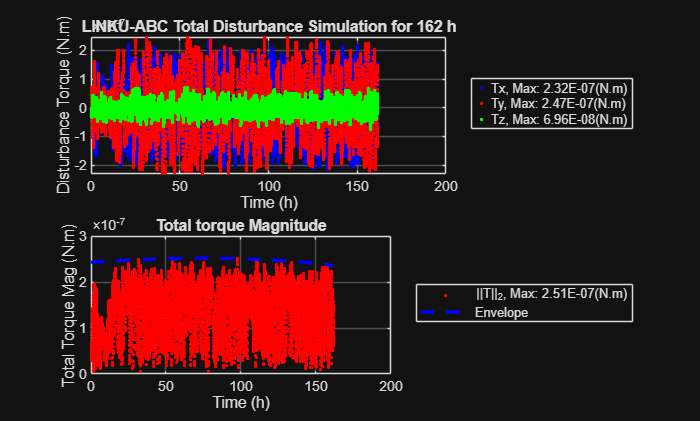

In [34]:
figure()
p1=subplot(2,1,1);
h1 = plot(tout/3600,totaltorque(1,:),'b.','LineWidth',0.5);
hold on; grid on;
h2 = plot(tout/3600,totaltorque(2,:),'r.','LineWidth',0.5);
h3 = plot(tout/3600,totaltorque(3,:),'g.','LineWidth',0.5);
xlabel('Time (h)');
ylabel('Disturbance Torque (N.m)');
legend([h1,h2,h3],['Tx, Max: ', num2str(max(totaltorque(1,:)),'%.2E'),'(N.m)'],...
                  ['Ty, Max: ', num2str(max(totaltorque(2,:)),'%.2E'),'(N.m)'],...
                  ['Tz, Max: ', num2str(max(totaltorque(3,:)),'%.2E'),'(N.m)'],'Location','eastoutside');
title(['LINKU-ABC Total Disturbance Simulation for ', num2str(round(tout(end)/3600)), ' h']);


p2=subplot(2,1,2);
envelope_signal = envelope(normTtorque,3E3,'peak');
h1 = plot(tout/3600,normTtorque,'r.','LineWidth',0.5);hold on;
h2 = plot(tout/3600,envelope_signal,'b--','LineWidth',2);
xlabel('Time (h)'); grid on;
ylabel('Total Torque Mag (N.m)');
legend([h1,h2],['||T||_2, Max: ', num2str(max(normTtorque),'%.2E'),'(N.m)'] ,'Envelope','Location','eastoutside');
title('Total torque Magnitude');
linkaxes([p1,p2],'x');


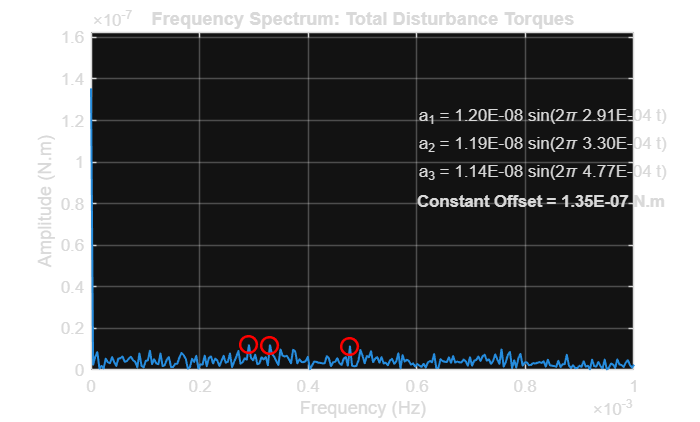

In [35]:
%%FFT analisys
[top_three_pks, top_three_freq, constant, t_uniform, x_uniform] = fftAnalisys(90,tout,normTtorque);


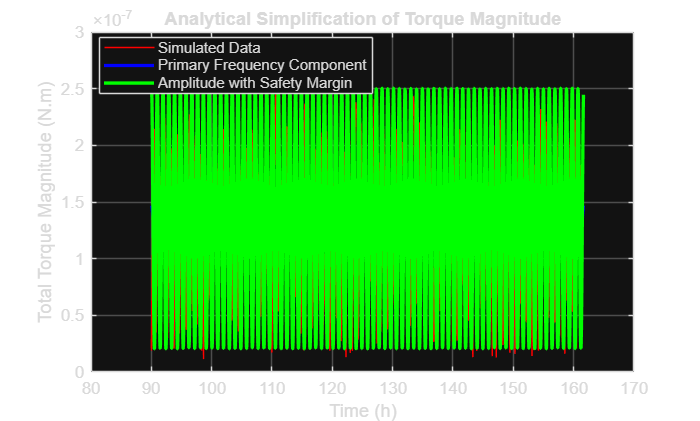

In [36]:
%% 1. SINE-WAVE DISTURBANCE RECONSTRUCTION
% Sinusoidal signals are generated based on the highest amplitude frequency
% components identified in the FFT analysis.


% Individual components (Primary harmonics)
sen1 = top_three_pks(1)*sin(2*pi*top_three_freq(1)*t_uniform);
sen2 = top_three_pks(2)*sin(2*pi*top_three_freq(2)*t_uniform);
sen3 = top_three_pks(3)*sin(2*pi*top_three_freq(3)*t_uniform);


% "Worst-Case" Model (Safety Margin)
% Utilizes the primary frequency but scales the amplitude to cover the
% maximum peak observed in the original simulation (normTtorque).
peakSen1 = (max(normTtorque) - constant) * sin(2*pi*top_three_freq(1)*t_uniform);


%% 2. COMPARISON AND DESIGN MARGIN VISUALIZATION
figure('Color', 'w', 'Name', 'Torque Model Validation');


% Plot original interpolated data (Reference baseline)
h1 = plot(t_uniform/3600, x_uniform, 'r-', 'LineWidth', 0.5); hold on; grid on;


% Plot reconstruction of the dominant frequency + constant offset (DC bias)
h2 = plot(t_uniform/3600, sen1 + constant, 'b-', 'LineWidth', 2);


% Plot the safety model (Analytical Envelope)
% This model is typically used to stress-test ADCS robustness.
h3 = plot(t_uniform/3600, peakSen1 + constant, 'g-', 'LineWidth', 2);


% Label and Legend Configuration
legend([h1, h2, h3], ...
       {'Simulated Data', ...
        'Primary Frequency Component', ...
        'Amplitude with Safety Margin'}, ...
       'Location', 'best');


xlabel('Time (h)');
ylabel('Total Torque Magnitude (N.m)');
title('Analytical Simplification of Torque Magnitude');

In [37]:
% Calcular el error residual entre la simulación y el modelo simplificado
error_residual = x_uniform - (sen1 + constant);


% Calcular el Error Cuadrático Medio (RMSE)
rmse_torque = sqrt(mean(error_residual.^2));


% Calcular el error relativo respecto al pico máximo (%)
error_relativo = (rmse_torque / max(x_uniform)) * 100;


fprintf('--- Validación del Modelo Analítico ---\n');

--- Validación del Modelo Analítico ---

In [38]:
fprintf('RMSE del Torque: %.2E N.m\n', rmse_torque);

RMSE del Torque: 5.63E-08 N.m

In [39]:
fprintf('Error Relativo: %.2f%%\n', error_relativo);

Error Relativo: 22.43%

In [40]:
function [x_dot] = mySatellite(t, x, sat, earth , Td)%#ok
%%% Inputs
% t: current time
% x: satellite state
% sat: Satellite parameters
% earth: Earth parameters
% Td: External Disturbances


%%% Read state input
r   =  x(1:3);
vel =  x(4:6);
q   =  x(7:10);
w   =  x(11:13);


%% Read Satellite physical parameters
m  = sat.mass;
Is = sat.Is;


%%%Translational Dynamics
%%%Earth gravity Model
rho = norm(r);
rhat = r/rho;
Fgrav = -(earth.GravityConst*earth.Mass*m/rho^2)*rhat;
F = Fgrav;
accel = F/m;


%%%Rotational Dynamics
%%Book: Fundamentals of Spacecraft Attitude Determination and Control
%%Author: F. Landis Markley & John L. Crassidis
%%Quaternions Kinematics..Ecuación (2.88)
Xi=[-q(2),-q(3),-q(4);
    q(1),-q(4),q(3);
    q(4),q(1),-q(2);
    -q(3),q(2),q(1)];
q_dot=1/2*Xi*w;
%%%Kynematics Equation(3.21)
H = Is*w;                         %Satellite Angular momentun
w_dot = Is\(Td - cross(w,H));     %Dynamics Equatión (3.147)
%%%x_dot Vector
x_dot=[vel;accel;q_dot;w_dot];
end


function [x_dot] = satelliteSim(t, x, sat, earth, dist, settings)
% SATELLITESIM Integrador dinámico optimizado para CubeSat 12U.
% Registra telemetría interna y gestiona perturbaciones ambientales.


    % Variables globales para el sistema de telemetría virtual
    global varNames curValues varValues
    persistent availableVars lastUpdate

    %% --- 1. CÁLCULO DE PERTURBACIONES ---
    % Se obtienen los torques (Tgg, Tsp, Tdrag) basados en el estado actual x
    Td = dist(x);


    %% --- 2. MODELO FÍSICO DEL SATÉLITE ---
    % Calcula la cinemática y dinámica (Ecuaciones de Euler)
    x_dot = mySatellite(t, x, sat, earth , Td);


    %% --- 3. CONTROL DE BARRA DE PROGRESO (4 Actualizaciones) ---
    if t == 0 || isempty(lastUpdate)
        lastUpdate = 0;
    end


    progress = t / settings.tfinal;
    milestones = [0.25, 0.50, 0.75, 1.0];


    if isa(settings.hWaitbar,'handle') && isvalid(settings.hWaitbar)
        % Encontrar el hito más cercano alcanzado
        currentMilestone = milestones(find(progress >= milestones, 1, 'last'));

        if ~isempty(currentMilestone) && currentMilestone > lastUpdate
            if t >= settings.tfinal || currentMilestone == 1.0
                waitbar(1.0, settings.hWaitbar, 'Progreso: 100% - Completado');
                lastUpdate = 1.0;
                pause(0.5); % Breve pausa para visualizar el final
                delete(settings.hWaitbar); % Cierre automático
            else
                waitbar(currentMilestone, settings.hWaitbar, sprintf('Progreso: %.0f%%', currentMilestone*100));
                lastUpdate = currentMilestone;
            end
        end
    end


    %% --- 4. MECANISMO DE DATA LOGGING ---
    if t == 0
        availableVars = intersect(who, varNames);
        if ~isempty(availableVars)
            varValues.time = [];
            for i = 1: length(availableVars)
                varValues.([availableVars{i, 1}]) = [];
            end
        end
    end

    if ~isempty(availableVars)
        for i = 1: length(availableVars)
            curValues.([availableVars{i, 1}]) = eval(reshape(availableVars{i, 1}, [], 1));
        end
    end
end
function Tgg = dist_gravityGrad(state, sat, orbit, earth)
% DIST_GRAVITYGRAD Calcula el torque por gradiente de gravedad.
% Útil para satélites con inercias asimétricas como un CubeSat 12U.


    % 1. Extraer cuaternión (asumiendo formato [q_w, q_x, q_y, q_z])
    q = state(7:10);
    q = q / norm(q); % Normalización de seguridad


    % 2. Parámetros orbitales
    % Usar mu desde la estructura earth si está disponible, sino el estándar
    if isfield(earth, 'mu')
        mu = earth.mu;
    else
        mu = 3.986004418e14; % [m^3/s^2]
    end

    rc = earth.Radius + orbit.altitude;
    omega_o_sq = mu / rc^3; % Velocidad orbital al cuadrado (w_o^2)


    % 3. Dirección del Nadir en el marco del cuerpo (Body Frame)
    % Representa la dirección hacia el centro de la Tierra
    c3 = [2*(q(2)*q(4) - q(3)*q(1));
          2*(q(3)*q(4) + q(2)*q(1));
          1 - 2*(q(2)^2 + q(3)^2)];


    % 4. Cálculo del Torque de Gradiente de Gravedad
    % Tgg = 3 * w_o^2 * (n x (I * n))
    Tgg = 3 * omega_o_sq * cross(c3, sat.Is * c3);
end


function Tsp = dist_solRad(Aefec_vec, sat, sun_in_eclipse)
    % Aefec_vec: Vector de área efectiva [3x1] (salida de tu función anterior)
    % sat: Estructura con .q_reflec (0 a 1) y .cp_cg (brazo de palanca [3x1])
    % sun_in_eclipse: Booleano (true si está en sombra, false si hay sol)


    if sun_in_eclipse
        Tsp = [0; 0; 0];
        return;
    end


    % --- Constantes ---
    P0 = 1367; % Constante solar promedio (W/m^2)
    c  = 299792458; % Velocidad de la luz (m/s)
    P_rad = P0 / c; % Presión de radiación (~4.57e-6 N/m^2)


    % --- Cálculo de la Fuerza (F) ---
    % Usamos el vector Aefec_vec que ya trae la dirección y magnitud proyectada.
    % La fuerza actúa en la dirección opuesta al sol (dirección de incidencia).
    % Nota: (1 + q_reflec) asume reflexión especular simplificada.
    F_srp = P_rad * (1 + sat.q_reflec) * Aefec_vec;


    % --- Cálculo del Torque (T = r x F) ---
    % sat.cp_cg debe ser el vector del Centro de Masas al Centro de Presiones [3x1]
    Tsp = cross(sat.cps_cg, F_srp);
end


function Tdrag = dist_aeroDrag(Aefec_vec, v_rel, rho, sat)
% Aefec_vec: Vector de área efectiva [3x1] (Salida de tu función efectiveArea)
% v_rel: Vector velocidad relativa a la atmósfera [3x1] (m/s)
% rho: Densidad atmosférica local (kg/m^3)
% sat: Estructura con .cd (coef. arrastre) y .cpa_cg (brazo de palanca [3x1])


    % 1. Calcular la magnitud de la velocidad
    v_mag = norm(v_rel);

    if v_mag == 0
        Tdrag = [0; 0; 0];
        return;
    end


    % 2. Calcular el vector Fuerza de Arrastre (Drag)
    % La fuerza de arrastre se opone al vector de velocidad relativa.
    % Usamos Aefec_vec que ya contiene la proyección geométrica.
    % Fd = -1/2 * rho * Cd * A_proyectada * v^2 * unit(v)

    F_drag = -0.5 * rho * sat.cd * v_mag * v_rel * norm(Aefec_vec);


    % 3. Calcular el Torque Aerodinámico (T = r x F)
    % sat.cpa_cg: Vector desde el CG al Centro de Presiones Aerodinámicas.
    Tdrag = cross(sat.cpa_cg, F_drag);
end


function rotX = quatRotation(q, x)
    % q: Cuaternión [1x4] o [4x1]
    % x: Matriz de vectores [3xN] donde N es el número de vectores (como tus 6 caras)

    n = size(x, 2); % Cantidad de vectores
    q = reshape(q, 1, 4); % Asegurar que q sea fila para quatmultiply

    % 1. Convertir los vectores x en cuaterniones puros (parte escalar = 0)
    % qx debe ser [Nx4] -> [0, x1, x2, x3]
    qx = [zeros(n, 1), x'];

    % 2. Expandir q para que tenga el mismo número de filas que qx
    % Esto permite que quatmultiply opere par a par
    q_rep = repmat(q, n, 1);

    % 3. Realizar la operación: q * qx * conj(q)
    % quatmultiply en MATLAB opera sobre matrices de [Nx4]
    q_conj = [q(1), -q(2:4)]; % Conjugado manual para mayor velocidad

    temp = quatmultiply(q_rep, qx);
    qrotX = quatmultiply(temp, repmat(q_conj, n, 1));

    % 4. Extraer las partes vectoriales resultantes [3xN]
    rotX = qrotX(:, 2:4)';
end


function [x_dot] = mySatelliteSPG4(t, x, sat, Td)%#ok
%%% Inputs
% t: current time
% x: satellite state
% sat: Satellite parameters
% earth: Earth parameters
% Td: External Disturbances


%%% Read state input
q   =  x(1:4);
w   =  x(5:7);


%% Read Satellite physical parameters
m  = sat.mass; %#ok
Is = sat.Is;


%%%Rotational Dynamics
%%Book: Fundamentals of Spacecraft Attitude Determination and Control
%%Author: F. Landis Markley & John L. Crassidis
%%Quaternions Kinematics..Ecuación (2.88)
Xi=[-q(2),-q(3),-q(4);
    q(1),-q(4),q(3);
    q(4),q(1),-q(2);
    -q(3),q(2),q(1)];
q_dot=1/2*Xi*w;
%%%Kynematics Equation(3.21)
H = Is*w;                         %Satellite Angular momentun
w_dot = Is\(Td - cross(w,H));     %Dynamics Equatión (3.147)
%%%x_dot Vector
x_dot=[q_dot;w_dot];
end


function [x_dot] = satelliteSPG4sim(t, x, sat, dist1, dist2, dist3, settings)
% SATELLITESPG4SIM Integrador dinámico con propagación SGP4 y telemetría.
% LS2125204: bespi123
%
% Esta función calcula las derivadas de actitud [q_dot; w_dot] integrando
% la posición orbital exacta para determinar eclipses y áreas efectivas.


    % Variable persistente para controlar que la barra solo se actualice 4 veces
    persistent lastUpdate
    if t == 0 || isempty(lastUpdate)
        lastUpdate = 0;
    end


    %% 1. OBTENCIÓN DE ESTADOS Y GEOMETRÍA SOLAR
    % Sincronización de tiempo con el objeto SGP4 del satélite
    datetime_t = settings.startTime + seconds(t);
    [positionGCRF, velGCRF] = states(sat.satSGP4, datetime_t, "CoordinateFrame", "inertial");

    % Posición del sol y determinación de Eclipse
    [sun_i, r_sun] = solar(datetime_t.Year, datetime_t.Month, datetime_t.Day, ...
                           datetime_t.Hour, datetime_t.Minute, datetime_t.Second);
    sun_avail = eclipse(positionGCRF, r_sun*sun_i);


    %% 2. MARCOS DE REFERENCIA (Orbit to Inertial)
    % Construcción de la matriz de rotación del marco orbital (VVLH) al inercial
    oX = getUnitVector(velGCRF);
    oZ = -1 * getUnitVector(positionGCRF); % Dirección Nadir
    oY = cross(oZ, oX);
    rot_orbit_I = horzcat(oX, oY, oZ);

    %% 3. CÁLCULO DE PERTURBACIONES (Torques)
    % A. Gradiente de Gravedad
    Tgg = dist1([zeros(6,1); x]);


    % B. Arrastre Aerodinámico (Drag)
    % Se calcula el área proyectada en la dirección del movimiento (Body Frame)
    AefecDrag = efectiveArea(quatRotation(quatconj(x(1:4)'), [1,0,0]'), ...
                             sat.faceAreas, [1;0;0;0], false);
    Tdrag = dist3(AefecDrag, velGCRF);


    % C. Presión de Radiación Solar
    if sun_avail == 1
        sun_orbit = rot_orbit_I' * sun_i'; % Sol en marco orbital
        % Área efectiva en Body Frame considerando la actitud actual x
        Aefecb = efectiveArea(quatRotation(quatconj(x(1:4)'), sun_orbit), ...
                              sat.faceAreas, [1;0;0;0], false);
        Tsolar = dist2(Aefecb);
    else
        Tsolar = zeros(3, 1);
    end


    %% 4. MODELO DINÁMICO
    Td = Tgg + Tsolar + Tdrag;
    x_dot = mySatelliteSPG4(t, x, sat, Td);


    %% 5. CONFIGURACIÓN DE WAITBAR (Actualización cada 25%)
    progress = t / settings.tfinal;
    milestones = [0.25, 0.50, 0.75, 1.0]; % Hitos de actualización

    if isa(settings.hWaitbar, 'handle') && isvalid(settings.hWaitbar)
        % Encontrar el hito más alto alcanzado por el progreso actual
        currentMilestone = milestones(find(progress >= milestones, 1, 'last'));

        if ~isempty(currentMilestone) && currentMilestone > lastUpdate
            if t >= settings.tfinal || currentMilestone == 1.0
                waitbar(1.0, settings.hWaitbar, 'Progreso: 100% - Completado');
                lastUpdate = 1.1; % Bloquea futuras actualizaciones en este ciclo
                pause(0.5);       % Pausa para que el usuario vea el final
                delete(settings.hWaitbar);
            else
                waitbar(currentMilestone, settings.hWaitbar, ...
                        sprintf('Progreso: %.0f%%', currentMilestone*100));
                lastUpdate = currentMilestone;
            end
        end
    end
end


function Aefec = efectiveArea(v, Area, q, debug)
% EFECTIVEAREA Calcula el vector de área efectiva proyectada de un CubeSat.
%
%   AEFEC = EFECTIVEAREA(V, AREA, Q, DEBUG) calcula la proyección de las caras
%   de un paralelepípedo (CubeSat) en la dirección de un vector de incidencia V
%   (flujo atmosférico o radiación solar), considerando la actitud Q.
%
%   INPUTS:
%       v     : Vector de incidencia [3x1] en el marco inercial (ej. Velocidad).
%       Area  : Áreas de las caras [1x6] o [6x1] en orden [X+ Y+ Z+ X- Y- Z-].
%               Si es un escalar, se asume un cubo con caras iguales.
%       q     : Cuaternión de actitud [4x1] que define la rotación del
%               marco del cuerpo al marco inercial (Body -> Inercial).
%       debug : Booleano (true/false) para activar visualización 3D.
%
%   OUTPUTS:
%       Aefec : Vector área efectiva [3x1] en el marco inercial. La magnitud
%               norm(Aefec) es el área escalar proyectada total (m^2).
%
%   EJEMPLO PARA CUBESAT 12U:
%       Areas12U = [0.06, 0.06, 0.04, 0.06, 0.06, 0.04]; % m^2
%       A = efectiveArea([7800;0;0], Areas12U, [1;0;0;0], true);
%
%   NOTAS:
%       Esta función es crítica para el cálculo de torques de perturbación
%       por arrastre atmosférico (Drag) y presión de radiación solar (SRP).
%
%   Autor: [Tu Nombre / Proyecto MistiSat]
%   Fecha: 26-Ene-2026


    % --- Validación de Entrada ---
    if isscalar(Area)
        Area = Area * ones(6, 1);
    end


    % --- Definición de Geometría ---
    % Normales unitarias en el marco del cuerpo (Body Frame)
    % [X+, Y+, Z+, X-, Y-, Z-]
    sides = [eye(3), -eye(3)];

    % --- Transformación de Coordenadas ---
    % Se rotan las normales al marco inercial para compararlas con v
    rotSides = quatRotation(q, sides);

    % --- Cálculo Geométrico ---
    dir = v / norm(v); % Vector unitario de la fuente incidente

    % Producto punto vectorizado: cos(theta) entre v y cada cara
    cos_theta = dir' * rotSides;

    % Criterio de visibilidad: solo caras orientadas hacia la fuente (cos > 0)
    visible = cos_theta > 0;

    % --- Composición del Vector Resultante ---
    % Pondera cada normal por su área correspondiente y el coseno del ángulo
    contributions = (Area(:)' .* cos_theta) .* visible;

    % Suma vectorial de todas las contribuciones proyectadas
    Aefec = rotSides * contributions';


    % --- Visualización (Opcional) ---
    if debug
        figure('Name', 'Visualización de Área Efectiva 12U');
        hold on; grid on; axis equal;
        view(3); % Vista 3D

        % Dibujar el vector de incidencia (v) en verde
        plotVector(zeros(3,1), dir, 1, 'g-', 'Incidencia (v)', 'e');

        % Colores para las caras: X (Rojo), Y (Verde), Z (Azul)
        colors = {'r-', 'g-', 'b-', 'r--', 'g--', 'b--'};

        for i = 1:6
            % Dibujar la normal rotada de la cara
            origin = zeros(3,1);
            plotVector(origin, rotSides(:,i), 0.8, colors{i}, ['N_', num2str(i)], 'e');

            % Si la cara es visible, dibujar su contribución proyectada en cian
            if visible(i)
                % La proyección es (cos_theta * normal)
                projVec = cos_theta(i) * rotSides(:,i);
                plotVector(origin, projVec, 1, 'c-', ['proj_', num2str(i)], 'e');
            end
        end

        % Dibujar el vector resultante final (Aefec) en negro grueso
        plotVector(zeros(3,1), Aefec/norm(Aefec), 1.2, 'k-', 'A_total', 'e');

        title(['Área Proyectada Total: ', num2str(norm(Aefec)), ' m^2']);
        xlabel('X (Inercial)'); ylabel('Y (Inercial)'); zlabel('Z (Inercial)');
    end
end


function u = getUnitVector(vector)
    u = vector/norm(vector);
end


function [top_three_pks, top_three_freq, constant, t_uniform, x_uniform] = fftAnalisys(t_start, tout, normTtorque)
% FFTANALISYS Análisis espectral robusto para torques de perturbación.
%
%   Esta función descompone la señal de torque en sus componentes de frecuencia
%   principales, utilizando una búsqueda de tiempo basada en proximidad para
%   evitar errores de tolerancia y una interpolación spline para uniformidad.
%
%   INPUTS:
%       t_start     : Tiempo de inicio del análisis (en horas).
%       tout        : Vector de tiempo de simulación (en segundos).
%       normTtorque : Magnitud del torque de perturbación ||Td|| (N.m).


    %% 1. EXTRACCIÓN DEL SEGMENTO DE DATOS
    % Sustitución de 'find' por 'min' para garantizar robustez ante el paso variable
    [~, idx_start] = min(abs(t_start - (tout/3600)));

    t_segment = tout(idx_start:end);
    torque_segment = normTtorque(idx_start:end);


    %% 2. REGULARIZACIÓN DE LA SEÑAL (Muestreo Uniforme)
    % La FFT requiere un intervalo de tiempo constante (delta t)
    temp = diff(t_segment);
    t_sample = mean(temp); % Usamos el promedio para estabilizar la frecuencia de muestreo

    % Definir vector de tiempo uniforme y realizar interpolación spline
    t_uniform = t_segment(1):t_sample:t_segment(end);
    x_uniform = interp1(t_segment, torque_segment, t_uniform, 'spline');

    %% 3. TRANSFORMADA RÁPIDA DE FOURIER (FFT)
    Fs = 1 / (t_uniform(2) - t_uniform(1)); % Frecuencia de muestreo (Hz)
    L = length(x_uniform);                 % Longitud de la señal
    Y = fft(x_uniform);                    % Transformada

    % Cálculo del espectro de amplitud unilateral
    P2 = abs(Y/L);
    P1 = P2(1:floor(L/2)+1);
    P1(2:end-1) = 2*P1(2:end-1);
    f = Fs*(0:(floor(L/2)))/L; % Vector de frecuencias

    %% 4. IDENTIFICACIÓN DE COMPONENTES DOMINANTES
    % Filtrado de picos significativos
    [pks, locs] = findpeaks(P1);

    % Ordenar picos por magnitud descendente
    [sorted_pks, sorted_idx] = sort(pks, 'descend');

    % Extraer los 3 componentes principales
    top_three_pks = sorted_pks(1:3);
    top_three_locs = locs(sorted_idx(1:3));
    top_three_freq = f(top_three_locs);

    % Componente DC (Valor constante u offset)
    constant = P1(1);

    %% 5. VISUALIZACIÓN DE RESULTADOS
    figure('Color', 'w', 'Name', 'Torque Frequency Analysis');
    plot(f, P1, 'LineWidth', 1.2); hold on;
    plot(top_three_freq, top_three_pks, 'ro', 'MarkerSize', 10, 'LineWidth', 1.5);

    title('Frequency Spectrum: Total Disturbance Torques');
    xlabel('Frequency (Hz)'); ylabel('Amplitude (N.m)');
    grid on;

    % Automatic axis scaling for better visualization
    xlim([0 0.001]);
    ylim([0 max(P1)*1.2]);

    % Resulting Mathematical Model Annotation
    % Using a dynamic X-position based on current axis limits
    text_x = 0.0006;
    text(text_x, max(P1)*0.9, sprintf('a_1 = %.2E sin(2\\pi %.2E t)', top_three_pks(1), top_three_freq(1)));
    text(text_x, max(P1)*0.8, sprintf('a_2 = %.2E sin(2\\pi %.2E t)', top_three_pks(2), top_three_freq(2)));
    text(text_x, max(P1)*0.7, sprintf('a_3 = %.2E sin(2\\pi %.2E t)', top_three_pks(3), top_three_freq(3)));
    text(text_x, max(P1)*0.6, sprintf('Constant Offset = %.2E N.m', constant), 'FontWeight', 'bold');
end


%%------------------------ Plot functions------------------
function [h1,h2] = plotVector(v0,v,scale,style,label,labelLocation)
if labelLocation=='m'
    scale = scale*1.1;
    h1 = quiver3(v0(1), v0(2), v0(3), v(1)*scale, v(2)*scale, v(3)*scale, style);
    h2 = text(v0(1)+v(1)*scale/2,v0(2)+v(2)*scale/2, v0(3)+v(3)*scale/2, label,'Color',style(1));
else
    h1 = quiver3(v0(1)*scale, v0(2)*scale, v0(3)*scale, v(1)*scale, v(2)*scale, v(3)*scale, style);
    h2 = text((v0(1)+v(1))*scale, (v0(2)+v(2))*scale, (v0(3)+v(3))*scale, label,'Color',style(1));
end


% Set equal axis scales and display grid
axis equal
grid on
end


function [h1,h2] = plotPoint(P,style,label,pos)
h1 = plot3(P(1),P(2),P(3),style);
h2 = text(P(1)+pos,P(2)+pos,P(3)+pos,label,'Color',style(1));
end


function [value, isterminal, direction] = store_var(t,x)%#ok

    global curValues varValues

     %%%Store Global variables
    fieldName = fields(curValues);

    varValues.time = horzcat(varValues.time, t);

    for i = 1:numel(fieldName)
       varValues.([fieldName{i,1}]) = horzcat(varValues.([fieldName{i,1}]), curValues.([fieldName{i, 1}]));
    end


    value = 1; % Evento siempre ocurre
    isterminal = 0; % No detener la simulación
    direction = 0; % Ambas direcciones
end


**BIBLIOGRAPHY**

\[1\] Markley, F. Landis, and John L. Crassidis. *Fundamentals of spacecraft attitude determination and control*. Vol. 1286. New York, NY: Springer New York, 2014.

\[2\]Kök, Ibrahim. "Comparison and analysis of attitude control systems of a satellite using reaction wheel actuators." (2012).